# **GEOG5990M Spatial Data Science Report**

###  COURSEWORK COVERSHEET
- Student ID number: 201977905
- Module code: 25/26(2) GEOG5990M
- Module title: Programming for Geographical Information Analysis: Core Skills (28787)
- Assignment title: Spatial Data Science Report
- Marker:
- Declared word count: 1241 (excluding AI Acknowledgements of each chapter)


#### Use of Generative Artificial Intelligence (Gen AI) in this assessment – delete one statement as appropriate

- I have used Gen AI only for the specific purposes outlined in my acknowledgements


By submitting the work in this notebook you confirm your compliance with the University’s definition of Academic Integrity as: “a commitment to good study practices and shared values which ensures that my work is a true expression of my own understanding and ideas, giving credit to others where their work contributes to mine”. Double-check that your referencing and use of quotations is consistent with this commitment.

You also confirm that your declared word count accurately reflects the number of words in your submission, excluding the overall title, Gen AI use acknowledgement, bibliography/reference list, text/numbers in tables and figures (although table and figure captions are included in the word count).

# **Investigating Food Venue Concentration and Daytime Noise Complaints in Leeds**

### **This project examines whether areas with more Food & Drink venues in Leeds also experience higher levels of daytime noise nuisance complaints. It cleans and integrates venue, noise, postcode, boundary, and population data; aggregates records to postcode sectors; tests the relationship statistically; identifies high food/high noise priority sectors; and presents both non-spatial and spatial visualisations for public-sector interpretation.**



---


# **A. Data Preparation and Organization**


---




## 1. Load required libraries


This section imports the libraries used for data cleaning, spatial processing, exploratory checking, and diagnostic visualisation. Pandas and numpy are used for tabular data handling, GeoPandas is used for spatial data and coordinate reference systems, and matplotlib is used to create visual checks during cleaning.

In [15]:
# Import regular expression for pattern matching
import re
# Import warnings to control non-critical warnings
import warnings

# Import libraries for data analysis, spatial data, and plotting
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Ignore non-critical warnings
warnings.filterwarnings("ignore")

## 2. Set project paths



This section defines the raw data sources used in the project, including Food & Drink venues, daytime noise complaints, ONSPD postcode data, Leeds boundary data, and LSOA population data. Using fixed source paths or URLs keeps the workflow consistent and reduces the risk of loading different files at different stages. Food & Drink records are venue-based, Noise records are complaint-based and postcode-based, ONSPD provides postcode-to-coordinate lookup information, and boundary/population data provide area-level context, it also links UK postcodes to coordinates and administrative geographies.




---


**AI Acknowledgement:**

I acknowledge the use of Chatgpt - 5.5 Thinking (OpenAI, https://chatgpt.com/) to help converting the GitHub URL into a fixed path.

Prompt: please guide me on how to convert the URL into a specific path so that I can easily access the link later?

Understanding: I understood that GitHub raw URLs allow `pandas` and `GeoPandas` to read files directly from the repository. I also learned to define fixed base paths first and then use a dictionary with f-strings to manage different data file links more clearly and reproducibly.

In [16]:
# Use GitHub raw links so pandas and GeoPandas can read the files directly
GITHUB_COMMIT_RAW = (
    "https://raw.githubusercontent.com/hanyueluo7-ops/GEOG5990M_Project/"
    "4f22688e26d9e3207ade01f0cfc66ed31bd2aa82/data_raw"
)
GITHUB_MAIN_RAW = (
    "https://raw.githubusercontent.com/hanyueluo7-ops/GEOG5990M_Project/"
    "refs/heads/main/data_raw"
)
DATA_URLS = {
    "food": f"{GITHUB_COMMIT_RAW}/Leeds_Food%26Drink.csv",
    "noise": f"{GITHUB_MAIN_RAW}/Leeds_Noise.csv",
    "onspd": f"{GITHUB_COMMIT_RAW}/Leeds_ONSPD.csv",
    "boundary": f"{GITHUB_COMMIT_RAW}/Leeds.geojson",
    "population": f"{GITHUB_COMMIT_RAW}/Leeds_lsoa_resident_pop.csv",
}

## 3. Standardize data cleaning



This section defines reusable cleaning functions for reading CSV files, standardising column names, validating required fields, and cleaning UK postcodes, makes the workflow more consistent. Full postcodes are standardised before matching, while postcode sectors are extracted to support area-level comparison.


---


**AI Acknowledgement:**

I acknowledge the use of Chatgpt - 5.5 Thinking (OpenAI, https://chatgpt.com/) to help constructing standardized column names, checking necessary fields, and cleaning standardized British postal codes.

Prompt: If I want to define a reusable data cleaning process, how can I improve it based on my existing cleaning process? What are the principles and basic framework of the related functions?

Understanding: I have learned how to build reusable cleaning functions instead of repeating similar cleaning steps for each dataset. I also understood how regular expressions can standardise column names, validate required fields, and clean UK postcodes into consistent full postcode and postcode-sector formats.

In [17]:
# 3.1 Define a function to read a CSV file or CSV URL
# **kwargs lets the function pass extra options to pd.read_csv()
def read_csv_auto(path_or_url, **kwargs):
    # Try several common encodings
    for encoding in ["utf-8", "utf-8-sig", "cp1252", "latin1"]:
        # Read the CSV with the current encoding
        try:
            return pd.read_csv(path_or_url, encoding=encoding, **kwargs)
        # If the encoding fails, try the next one
        except UnicodeDecodeError:
            continue
    # Raise an error if all encodings fail
    raise ValueError(f"Could not read CSV source: {path_or_url}")


# 3.2 Define a function for basic table cleaning
def prepare_dataframe(df):
    # Copy the data so the raw data is not changed
    df = df.copy()
    # Clean all column names
    df.columns = [
        # Make column names lower case and replace spaces or symbols with underscores
        re.sub(r"[^a-z0-9]+", "_", str(col).strip().lower()).strip("_")
        # Keep the geometry column name unchanged
        if col != "geometry" else col
        # Apply this to each column
        for col in df.columns
    ]
    # Loop through text columns
    for col in df.select_dtypes(include="object").columns:
        # Convert values to strings and trim spaces
        df[col] = df[col].astype(str).str.strip()
        # Replace fake missing values with real missing values
        df[col] = df[col].mask(
            df[col].str.lower().isin(["", "nan", "none", "null", "na", "<na>"]),
            np.nan,
        )
    # Return the cleaned DataFrame
    return df


# 3.3 Define a function to check required columns
def require_columns(df, required_columns, dataset_name):
    # Find required columns that are missing
    missing_columns = [col for col in required_columns if col not in df.columns]
    # Stop if any required column is missing
    if missing_columns:
        # Show which dataset and columns caused the problem
        raise ValueError(f"{dataset_name} is missing columns: {missing_columns}")


# 3.4 Define a function to find the first available column name
def first_existing_column(df, possible_columns):
    # Check each possible column name
    for col in possible_columns:
        # Return the column if it exists
        if col in df.columns:
            # Return the matched column name
            return col
    # Return None if no column is found
    return None


# 3.5 Define a function to clean full UK postcodes
def clean_full_postcode(value):
    # Check whether the value is missing
    if pd.isna(value):
        # Return missing if the input is missing
        return np.nan
    # Convert the postcode to upper case text
    postcode = str(value).upper().strip()
    # Remove spaces and symbols
    postcode = re.sub(r"[^A-Z0-9]", "", postcode)
    # Check whether the text is a full UK postcode
    match = re.match(r"^([A-Z]{1,2}\d[A-Z\d]?)(\d[A-Z]{2})$", postcode)
    if match:
        # Add the standard space in the postcode
        return f"{match.group(1)} {match.group(2)}"
    # Return missing if the postcode is not valid
    return np.nan


# 3.6 Define a function to extract postcode sector
def extract_postcode_sector(value):
    # Check whether the input is missing
    if pd.isna(value):
        return np.nan
    # Convert the input to upper case text
    postcode = str(value).upper().strip()
    # Remove spaces and symbols
    postcode = re.sub(r"[^A-Z0-9]", "", postcode)
    # Check whether the input is a full postcode
    full_match = re.match(r"^([A-Z]{1,2}\d[A-Z\d]?)(\d)[A-Z]{2}$", postcode)
    # Return the sector if the full postcode matches
    if full_match:
        return f"{full_match.group(1)} {full_match.group(2)}"
    # If not, check whether it is already a postcode sector
    sector_match = re.match(r"^([A-Z]{1,2}\d[A-Z\d]?)(\d)$", postcode)
    # Return the sector if it matches
    if sector_match:
        # Format the sector with a space
        return f"{sector_match.group(1)} {sector_match.group(2)}"
    # Return missing if no valid sector is found
    return np.nan

## 4. Data cleaning and spatial integration

This section applies the general cleaning rules to each dataset. ONSPD is cleaned into a postcode lookup table; Food & Drink records are matched to ONSPD coordinates; Noise records are cleaned by date and postcode sector; Leeds boundaries are aligned to the project CRS; and population data are prepared for joining to LSOA boundaries.

Separate cleaning functions are used because the datasets have different structures and quality issues. Food venue data requires postcode matching because it does not already contain reliable spatial geometry. Noise data is aggregated using reported postcodes because the source states that records contain postcodes provided by reporting persons and exclude anonymous or incomplete service requests.



---


**AI Acknowledgement:**

I acknowledge the use of Chatgpt - 5.5 Thinking (OpenAI, https://chatgpt.com/) to help improve the structure of dataset-specific cleaning functions.

Prompt: My data cleaning workflow produced errors such as missing postcode columns, failed joins between Food & Drink records and ONSPD, and possible CRS inconsistencies in the boundary data. How can I redesign the cleaning functions to check required fields, select alternative column names, validate coordinates and safely join population data to boundaries?

Understanding: I have learned how to separate general cleaning helpers from dataset-specific cleaning functions. I also understood how cleaned postcodes, lookup tables, merge indicators, valid coordinate checks and CRS conversion help make the spatial joining process more reliable and reproducible.

In [18]:
# 4.1 Define a function to clean ONSPD and create a postcode lookup table
def clean_onspd(onspd_raw):
    # Clean column names and text values
    onspd = prepare_dataframe(onspd_raw)
    # Find the postcode column in ONSPD
    postcode_col = first_existing_column(onspd, ["pcds", "pcd2", "pcd"])
    # Stop if no postcode column is found
    if postcode_col is None:
        raise ValueError("ONSPD postcode column not found. Expected one of: pcds, pcd2, pcd.")

    # Create a cleaned full postcode for matching
    onspd["postcode_clean"] = onspd[postcode_col].apply(clean_full_postcode)
    # Extract postcode sector for area-level analysis
    onspd["postcode_sector"] = onspd[postcode_col].apply(extract_postcode_sector)

    # Convert numeric fields for coordinates and indices
    numeric_cols = ["oseast1m", "osnrth1m", "lat", "long", "imd", "dointr", "doterm"]
    # Only convert columns that exist
    for col in numeric_cols:
        if col in onspd.columns:
            onspd[col] = pd.to_numeric(onspd[col], errors="coerce")

    # Keep fields needed for analysis and spatial matching
    keep_cols = [
        "postcode_clean",
        "postcode_sector",
        "oseast1m",
        "osnrth1m",
        "lat",
        "long",
        "lsoa11",
        "msoa11",
        "osward",
        "oslaua",
        "imd",
    ]
    # Keep only columns that exist in this file
    lookup_cols = [col for col in keep_cols if col in onspd.columns]

    # Build a lookup table by full postcode
    onspd_lookup = (
        onspd[lookup_cols]
        # Drop rows without a clean postcode
        .dropna(subset=["postcode_clean"])
        # Keep one row per postcode
        .drop_duplicates(subset=["postcode_clean"])
        # Rename the sector field to avoid confusion after merging
        .rename(columns={"postcode_sector": "onspd_postcode_sector"})
        .copy()
    )

    # Return the cleaned ONSPD data and the lookup table
    return onspd, onspd_lookup


# 4.2 Define a function to clean Food & Drink data and match ONSPD coordinates
def clean_food(food_raw, onspd_lookup):
    # Clean the raw Food & Drink table
    food = prepare_dataframe(food_raw)
    # Check the key venue fields
    require_columns(food, ["venue_name", "venue_postcode"], "Food & Drink")

    # Create a clean full postcode for joining to ONSPD
    food["venue_postcode_clean"] = food["venue_postcode"].apply(clean_full_postcode)
    # Extract postcode sector for venue counts
    food["postcode_sector"] = food["venue_postcode"].apply(extract_postcode_sector)

    # Join ONSPD coordinates using the cleaned full postcode
    food_clean = food.merge(
        onspd_lookup,
        left_on="venue_postcode_clean",
        right_on="postcode_clean",
        how="left",
        # indicator=True records whether each row matched
        indicator=True,
    ).rename(columns={"_merge": "postcode_match"})

    # Convert the match result to text
    food_clean["postcode_match"] = food_clean["postcode_match"].astype(str)
    # Check whether each food venue has British National Grid coordinates
    food_clean["has_valid_coordinates"] = (
        food_clean["oseast1m"].notna() & food_clean["osnrth1m"].notna()
    )
    # Drop rows without postcode sector because they cannot be aggregated
    food_clean = food_clean.dropna(subset=["postcode_sector"]).copy()

    # Convert the table to a GeoDataFrame using easting and northing
    food_gdf = gpd.GeoDataFrame(
        food_clean,
        geometry=gpd.points_from_xy(food_clean["oseast1m"], food_clean["osnrth1m"]),
        # EPSG:27700 is British National Grid
        crs="EPSG:27700",
    )
    # Set geometry to None where coordinates are not valid
    food_gdf.loc[~food_gdf["has_valid_coordinates"], "geometry"] = None

    # Return the cleaned table, matched table, and spatial table
    return food, food_clean, food_gdf


# 4.3 Define a function to clean Noise nuisance data and extract time and sector
def clean_noise(noise_raw):
    # Clean the raw Noise table
    noise = prepare_dataframe(noise_raw)
    # Check the key fields needed for noise complaint analysis
    require_columns(
        noise,
        ["sr_created_date", "sr_num", "enq_type", "enq_sub_type", "postcode"],
        "Noise nuisance",
    )

    # Convert complaint creation date to datetime
    noise["created_date"] = pd.to_datetime(
        noise["sr_created_date"],
        dayfirst=True,
        # Invalid dates become missing values
        errors="coerce",
    )
    # Extract month for possible time summaries
    noise["month"] = noise["created_date"].dt.to_period("M").astype(str)
    # Set month to missing where the date is invalid
    noise.loc[noise["created_date"].isna(), "month"] = np.nan
    # Extract postcode sector for comparison with Food data
    noise["postcode_sector"] = noise["postcode"].apply(extract_postcode_sector)

    # Keep only fields needed later
    keep_cols = [
        "sr_num",
        "created_date",
        "month",
        "enq_type",
        "enq_sub_type",
        "postcode",
        "postcode_sector",
    ]
    # Create the cleaned Noise table
    noise_clean = noise[keep_cols].copy()
    # Keep valid postcode-sector records for area-level analysis
    noise_clean_valid = noise_clean.dropna(subset=["postcode_sector"]).copy()

    # Return the full cleaned table and the valid-sector version
    return noise, noise_clean, noise_clean_valid


# 4.4 Define a function to clean Leeds boundary data and align CRS
def clean_boundary(boundary_raw):
    # Copy the boundary data
    boundary = boundary_raw.copy()
    # Check whether the original CRS is missing
    crs_missing = boundary.crs is None

    # Convert to EPSG:27700 if a CRS exists
    if not crs_missing:
        boundary = boundary.to_crs("EPSG:27700")

    # Clean fields and return whether CRS was missing
    return prepare_dataframe(boundary), crs_missing


# 4.5 Define a function to clean population data
def clean_population(pop_raw):
    # Clean the table and rename long fields
    pop = prepare_dataframe(pop_raw).rename(
        columns={
            "geography_code": "lsoa21cd",
            "residence_type_total_measures_value": "population_total",
        }
    )

    # Stop if the population field is missing
    if "population_total" not in pop.columns:
        raise ValueError("Population column not found. Please check the population CSV columns.")

    # Convert population to numeric values
    pop["population_total"] = pd.to_numeric(pop["population_total"], errors="coerce")
    # Keep fields needed for population analysis and boundary joins
    keep_cols = [
        col
        for col in ["date", "geography", "lsoa21cd", "population_total"]
        if col in pop.columns
    ]

    # Return the cleaned population table
    return pop[keep_cols].copy()


# 4.6 Define a function to join population data to Leeds boundaries
def join_population_to_boundary(leeds_boundary, pop_clean):
    # Find the LSOA field in the boundary data
    boundary_lsoa_col = first_existing_column(
        leeds_boundary,
        ["lsoa21cd", "lsoa11cd", "lsoa21_code", "lsoa11_code", "geography_code"],
    )

    # Return the original boundary if no join field is found
    if boundary_lsoa_col is None or "lsoa21cd" not in pop_clean.columns:
        return leeds_boundary.copy(), boundary_lsoa_col

    # Join total population by LSOA code
    boundary_with_population = leeds_boundary.merge(
        pop_clean[["lsoa21cd", "population_total"]],
        left_on=boundary_lsoa_col,
        right_on="lsoa21cd",
        how="left",
    )

    # Return the joined boundary and the join field name
    return boundary_with_population, boundary_lsoa_col

## 5. Build cleaned datasets


This section reads the raw datasets and runs the cleaning functions to generate cleaned tabular and spatial outputs. The resulting objects include cleaned Food & Drink data, cleaned Noise records, an ONSPD lookup table, Leeds boundary data, population-joined boundary data, and GeoDataFrames for spatial analysis.

In [19]:
# 5.1 Read raw data
# Read CSV and GeoJSON files from GitHub raw links
food_raw = read_csv_auto(DATA_URLS["food"])
noise_raw = read_csv_auto(DATA_URLS["noise"])
onspd_raw = read_csv_auto(DATA_URLS["onspd"], low_memory=False)
pop_raw = read_csv_auto(DATA_URLS["population"])
leeds_boundary_raw = gpd.read_file(DATA_URLS["boundary"])


# 5.2 Run the cleaning functions
# Clean ONSPD, food venues, noise complaints, boundaries, and population data
onspd, onspd_lookup = clean_onspd(onspd_raw)
food, food_clean, food_gdf = clean_food(food_raw, onspd_lookup)
noise, noise_clean, noise_clean_valid = clean_noise(noise_raw)
leeds_boundary, boundary_crs_missing = clean_boundary(leeds_boundary_raw)
pop_clean = clean_population(pop_raw)
leeds_lsoa_pop, boundary_lsoa_col = join_population_to_boundary(leeds_boundary, pop_clean)

## 6. Spatial outputs for later analysis

This section aggregates Food & Drink venues and Noise complaints to postcode sectors and creates approximate sector centre points using average ONSPD coordinates. Food and Noise counts are then joined into one sector-level analysis table.

Food records are point/venue-based, while Noise records are primarily postcode-based. Aggregating both datasets to postcode sector creates a common spatial unit for comparison. Using sector centroids provides an approximate mapping location, but these points should be interpreted as summary locations rather than exact venue or complaint locations. This is important because postcode geographies do not perfectly align with administrative boundaries.



---


**AI Acknowledgement:**

I acknowledge the use of Chatgpt - 5.5 Thinking (OpenAI, https://chatgpt.com/) to help debug and improve the postcode-sector aggregation and centroid creation process.

Prompt: After aggregating Food & Drink venues and Noise complaints by postcode sector, some sectors have missing centroid coordinates after joining with ONSPD. How can I keep these sectors in the analysis while avoiding invalid point geometries in the GeoDataFrame?

Understanding: I understood that postcode-sector centroids are approximate summary locations calculated from ONSPD postcode coordinates, not exact complaint or venue locations. I also learned why an outer join is useful for keeping sectors with only food venues or only noise complaints, and why missing centroid geometries should be set to `None` rather than being plotted as invalid points.

In [20]:
# 6.1 Calculate postcode-sector centroids
# Use ONSPD records with valid sectors and coordinates
sector_centroids = (
    onspd.dropna(subset=["postcode_sector", "oseast1m", "osnrth1m"])
    # Group records by postcode sector
    .groupby("postcode_sector", as_index=False)
    # Calculate mean coordinates and postcode counts
    .agg(
        # Use mean easting as the approximate sector x coordinate
        sector_easting=("oseast1m", "mean"),
        # Use mean northing as the approximate sector y coordinate
        sector_northing=("osnrth1m", "mean"),
        # Count postcodes in each sector
        postcode_count=("postcode_clean", "count"),
    )
)

# Convert sector centroids to a GeoDataFrame
sector_centroids_gdf = gpd.GeoDataFrame(
    sector_centroids,
    # Create point geometry from mean coordinates
    geometry=gpd.points_from_xy(
        sector_centroids["sector_easting"],
        sector_centroids["sector_northing"],
    ),
    # Use British National Grid to match other spatial data
    crs="EPSG:27700",
)


# 6.2 Define a helper function to count records by postcode sector
# Food and Noise both need this same groupby step
def count_by_sector(df, count_col):
    # Count records in each postcode sector
    return (
        # Keep postcode_sector as a normal column
        df.groupby("postcode_sector", as_index=False)
        # Count rows in each group
        .size()
        # Rename the count column
        .rename(columns={"size": count_col})
    )


# 6.3 Count food venues and noise complaints by sector
# Count Food & Drink venues in each postcode sector
food_sector = count_by_sector(food_gdf, "food_venue_count")
# Count valid noise complaint records in each postcode sector
noise_sector = count_by_sector(noise_clean_valid, "daytime_noise_count")


# 6.4 Join Food, Noise, and sector centroid data
# First join Food and Noise count tables by postcode sector
sector_analysis = (
    food_sector
    # Use outer join so sectors with only Food or only Noise are kept
    .merge(noise_sector, on="postcode_sector", how="outer")
    # Add sector centroids and postcode counts
    .merge(
        # Keep only fields needed later
        sector_centroids[
            ["postcode_sector", "sector_easting", "sector_northing", "postcode_count"]
        ],
        on="postcode_sector",
        # Keep all Food/Noise sectors and add centroids where possible
        how="left",
    )
)
# Fill missing Food or Noise counts with 0
# This keeps count fields numeric and easy to interpret
count_cols = ["food_venue_count", "daytime_noise_count"]
sector_analysis[count_cols] = sector_analysis[count_cols].fillna(0).astype(int)


# 6.5 Convert the sector analysis table to a GeoDataFrame
# Create point geometry from sector centroid coordinates
sector_analysis_gdf = gpd.GeoDataFrame(
    sector_analysis,
    # Use sector centroid coordinates for point geometry
    geometry=gpd.points_from_xy(
        sector_analysis["sector_easting"],
        sector_analysis["sector_northing"],
    ),
    # Use EPSG:27700 to match the other spatial datasets
    crs="EPSG:27700",
)
# Set geometry to None where a sector has no centroid coordinates
# This can happen if the sector appears in Food or Noise but not in usable ONSPD coordinates
missing_centroid = (
    sector_analysis[["sector_easting", "sector_northing"]]
    # Check whether easting or northing is missing
    .isna()
    # Mark rows with either coordinate missing
    .any(axis=1)
)
# Keep attributes but avoid drawing invalid point locations
sector_analysis_gdf.loc[missing_centroid, "geometry"] = None

## 7. Compact cleaning summary

This section creates a compact cleaning summary showing raw record counts, cleaned record counts, valid postcode-sector records, ONSPD coordinate matches, missing centroid coordinates, and population join success. It also produces descriptive statistics and lists the postcode sectors with the highest Food and Noise counts.

Diagnostic bar charts are used to check missing values in the sector analysis table and to identify sectors with unusually high Food or Noise counts. These visual checks help assess whether postcode cleaning, ONSPD matching, aggregation, and joining have produced plausible results. If a sector has unexpectedly high values or missing centroid coordinates, the relevant raw records can be inspected before using the data in final analysis.


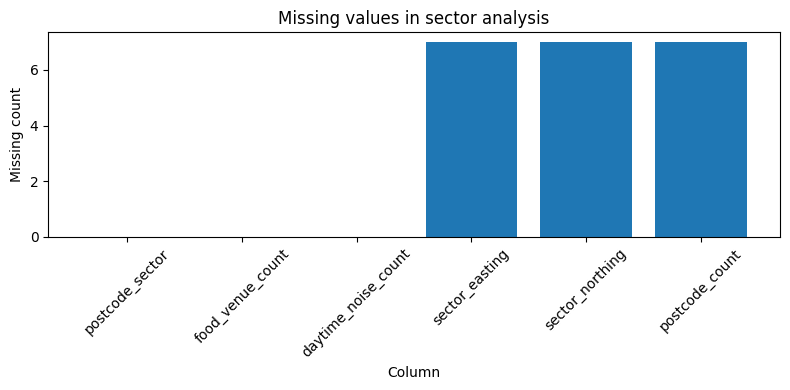

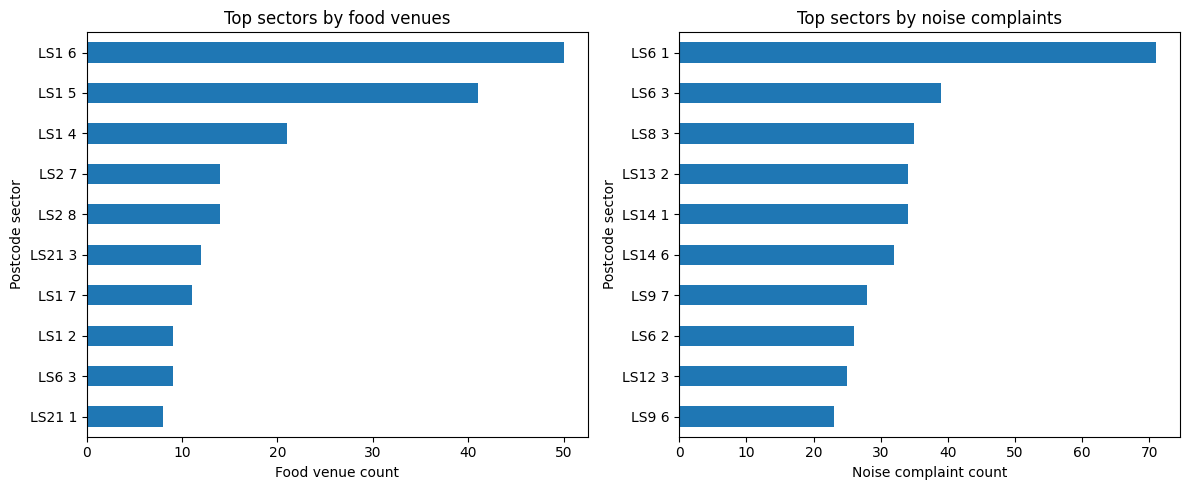

Cleaning, extraction, and joining results are kept in Python variables; no intermediate tables are saved.

Cleaning summary:
        dataset                       metric    value
   Food & Drink                  raw_records      282
   Food & Drink              cleaned_records      281
   Food & Drink        valid_postcode_sector      281
   Food & Drink matched_to_onspd_coordinates      281
          Noise                  raw_records     1148
          Noise              cleaned_records     1148
          Noise        valid_postcode_sector     1133
          Noise      invalid_postcode_sector       15
          ONSPD               lookup_records    31301
          ONSPD    postcode_sector_centroids      150
Sector analysis                      records      110
Sector analysis            sectors_with_food       49
Sector analysis           sectors_with_noise      102
       Boundary                      records      488
       Boundary       population_join_column lsoa21cd
       Boun

In [21]:
# 7.1 Calculate metrics used in the cleaning summary
# Name these values first to make the summary table easier to read
food_valid_sector_count = food_gdf["postcode_sector"].notna().sum()
food_matched_coordinate_count = food_gdf["has_valid_coordinates"].sum()
noise_invalid_sector_count = len(noise_clean) - len(noise_clean_valid)
sectors_with_food_count = (sector_analysis["food_venue_count"] > 0).sum()
sectors_with_noise_count = (sector_analysis["daytime_noise_count"] > 0).sum()

# Count boundary records with population values if the field exists
if "population_total" in leeds_lsoa_pop.columns:
    boundary_population_count = leeds_lsoa_pop["population_total"].notna().sum()
# Use 0 if the population field is missing
else:
    boundary_population_count = 0
# Record the boundary join column, or not_found if it is missing
population_join_column = boundary_lsoa_col or "not_found"


# 7.2 Build rows for the cleaning summary table
summary_rows = [
    # Food & Drink metrics check records, sectors, and coordinate matches
    ("Food & Drink", "raw_records", len(food_raw)),
    ("Food & Drink", "cleaned_records", len(food_gdf)),
    ("Food & Drink", "valid_postcode_sector", food_valid_sector_count),
    ("Food & Drink", "matched_to_onspd_coordinates", food_matched_coordinate_count),
    # Noise metrics check cleaned records and valid sector records
    ("Noise", "raw_records", len(noise_raw)),
    ("Noise", "cleaned_records", len(noise_clean)),
    ("Noise", "valid_postcode_sector", len(noise_clean_valid)),
    ("Noise", "invalid_postcode_sector", noise_invalid_sector_count),
    # ONSPD metrics check lookup size and sector centroid count
    ("ONSPD", "lookup_records", len(onspd_lookup)),
    ("ONSPD", "postcode_sector_centroids", len(sector_centroids_gdf)),
    # Sector analysis metrics check final sector coverage
    ("Sector analysis", "records", len(sector_analysis)),
    ("Sector analysis", "sectors_with_food", sectors_with_food_count),
    ("Sector analysis", "sectors_with_noise", sectors_with_noise_count),
    # Boundary metrics check boundary records and population matches
    ("Boundary", "records", len(leeds_boundary)),
    ("Boundary", "population_join_column", population_join_column),
    ("Boundary", "records_with_population", boundary_population_count),
    ("Boundary", "source_crs_missing", boundary_crs_missing),
]


# 7.3 Build a cleaning summary table
# Convert the metric rows into a DataFrame
cleaning_summary = pd.DataFrame(
    # Use the list of summary tuples
    summary_rows,
    # Name the three summary columns
    columns=["dataset", "metric", "value"],
)


# 7.4 Summarise numeric fields in the sector table
# Calculate basic descriptive statistics
sector_analysis_stats = sector_analysis.describe()


# 7.5 Count missing values in the sector table
sector_analysis_missing = (
    # Start with the sector-level analysis table
    sector_analysis
    # Mark missing cells as True
    .isna()
    # Count missing cells by column
    .sum()
    # Convert the result back to a table
    .reset_index(name="missing_count")
    # Rename the original column-name field
    .rename(columns={"index": "column"})
)


# 7.6 Select sectors with the highest counts
top_food_sectors = (
    # Start with the sector-level analysis table
    sector_analysis
    # Put the largest food counts first
    .sort_values("food_venue_count", ascending=False)
    # Keep the first 10 rows
    .head(10)
)
top_noise_sectors = (
    # Start with the sector-level analysis table
    sector_analysis
    # Put the largest noise counts first
    .sort_values("daytime_noise_count", ascending=False)
    # Keep the first 10 rows
    .head(10)
)


# 7.7 Plot simple diagnostic charts
# Create the missing-value chart area
fig, ax = plt.subplots(figsize=(8, 4))
# Draw one bar for each column's missing count
ax.bar(sector_analysis_missing["column"], sector_analysis_missing["missing_count"])
# Add the chart title
ax.set_title("Missing values in sector analysis")
# Label the x-axis
ax.set_xlabel("Column")
# Label the y-axis
ax.set_ylabel("Missing count")
# Rotate x labels so column names are readable
ax.tick_params(axis="x", rotation=45)
# Fit labels inside the figure
fig.tight_layout()
# Display the missing-value chart
plt.show()

# Create two side-by-side charts
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Plot top food sectors from low to high for readability
top_food_sectors.sort_values("food_venue_count").plot.barh(
    # Use postcode sector names on the y-axis
    x="postcode_sector",
    # Use food venue counts for bar length
    y="food_venue_count",
    # Draw on the left subplot
    ax=axes[0],
    # Hide the automatic legend
    legend=False,
)
# Add the left chart title
axes[0].set_title("Top sectors by food venues")
# Label the left chart x-axis
axes[0].set_xlabel("Food venue count")
# Label the left chart y-axis
axes[0].set_ylabel("Postcode sector")

# Plot top noise sectors from low to high for readability
top_noise_sectors.sort_values("daytime_noise_count").plot.barh(
    # Use postcode sector names on the y-axis
    x="postcode_sector",
    # Use noise complaint counts for bar length
    y="daytime_noise_count",
    # Draw on the right subplot
    ax=axes[1],
    # Hide the automatic legend
    legend=False,
)
# Add the right chart title
axes[1].set_title("Top sectors by noise complaints")
# Label the right chart x-axis
axes[1].set_xlabel("Noise complaint count")
# Label the right chart y-axis
axes[1].set_ylabel("Postcode sector")
# Fit both charts inside the figure
fig.tight_layout()
# Display the top-sector charts
plt.show()


# 7.8 Print final checking outputs
print("Cleaning, extraction, and joining results are kept in Python variables; no intermediate tables are saved.")
# Print the cleaning summary
print("\nCleaning summary:")
print(cleaning_summary.to_string(index=False))
# Print descriptive statistics for the sector table
print("\nDescriptive statistics for the sector analysis table:")
print(sector_analysis_stats.to_string())
# Print missing value counts
print("\nMissing values in the sector analysis table:")
print(sector_analysis_missing.to_string(index=False))
# Print sectors with the most food venues
print("\nTop 10 postcode sectors by food venue count:")
print(top_food_sectors.to_string(index=False))
# Print sectors with the most noise complaints
print("\nTop 10 postcode sectors by daytime noise complaint count:")
print(top_noise_sectors.to_string(index=False))



---


# **B. Discussion on the rationality before visualization**


---



## 8. Explore the relationship between variables

This section examines whether postcode sectors with more Food & Drink venues also tend to have more daytime noise complaints. Pearson and Spearman correlations are used as initial association checks, while a Poisson GLM is used because the dependent variable, daytime noise complaints, is count data.


---


**AI Acknowledgement:**

I acknowledge the use of Chatgpt - 5.5 Thinking (OpenAI, https://chatgpt.com/) to help understand and debug the statistical modelling section, especially the use of correlation tests and a Poisson GLM for count data.

Prompts:
- I want to test the relationship between food venue counts and daytime noise complaint counts by postcode sector. Since the response variable is count data, should I use a Poisson GLM instead of a simple linear regression?
- How can I avoid model errors when the predictor has no variation or the response count is zero?
- How should I interpret the IRR, p-value and dispersion?

Understanding: I have learned that Pearson and Spearman correlations provide simple association checks, while a Poisson GLM is more suitable for modelling complaint counts. I also understood that the model coefficient needs to be converted to an incidence rate ratio, and that the dispersion value helps check whether the Poisson model may be affected by overdispersion.

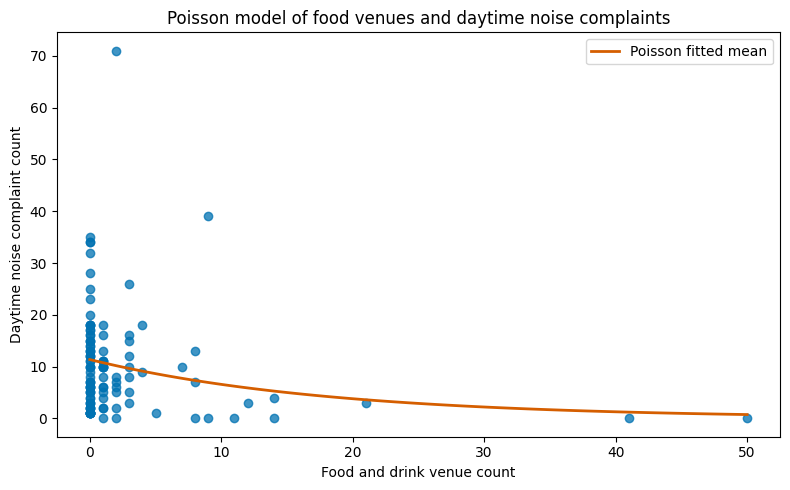


Relationship model summary:
             measure       value
    postcode_sectors         110
           pearson_r    -0.18371
          spearman_r   -0.216351
               model Poisson GLM
         poisson_irr    0.946604
poisson_irr_ci_lower    0.929622
poisson_irr_ci_upper    0.963895
     poisson_p_value         0.0
  poisson_dispersion   10.200025


In [22]:
# Import statsmodels for the Poisson GLM
import statsmodels.api as sm

# 8.1 Keep the two variables used in the model
relationship_vars = sector_analysis[
    ["food_venue_count", "daytime_noise_count"]
].dropna().copy()


# 8.2 Calculate correlation checks
pearson_corr = relationship_vars.corr(method="pearson").iloc[0, 1]
spearman_corr = relationship_vars.corr(method="spearman").iloc[0, 1]


# 8.3 Fit a Poisson GLM when statsmodels is available
poisson_model = None
poisson_prediction_line = None
poisson_summary_values = {
    "model": "Poisson GLM not estimated",
    "irr": np.nan,
    "ci_lower": np.nan,
    "ci_upper": np.nan,
    "p_value": np.nan,
    "dispersion": np.nan,
}

if (
    sm is not None
    and relationship_vars["food_venue_count"].nunique() > 1
    and relationship_vars["daytime_noise_count"].sum() > 0
):
    # Set the response variable
    y = relationship_vars["daytime_noise_count"]
    # Add an intercept to the predictor
    x = sm.add_constant(relationship_vars[["food_venue_count"]], has_constant="add")
    # Fit the count model
    poisson_model = sm.GLM(y, x, family=sm.families.Poisson()).fit()
    # Convert the coefficient to an incidence rate ratio
    food_irr = np.exp(poisson_model.params["food_venue_count"])
    # Convert the confidence interval to the IRR scale
    food_ci = np.exp(poisson_model.conf_int().loc["food_venue_count"])
    # Calculate a simple overdispersion check
    dispersion = poisson_model.pearson_chi2 / poisson_model.df_resid

    # Store compact model results
    poisson_summary_values = {
        "model": "Poisson GLM",
        "irr": food_irr,
        "ci_lower": food_ci.iloc[0],
        "ci_upper": food_ci.iloc[1],
        "p_value": poisson_model.pvalues["food_venue_count"],
        "dispersion": dispersion,
    }

    # Create values for the fitted line
    poisson_prediction_line = pd.DataFrame(
        {
            "food_venue_count": np.linspace(
                relationship_vars["food_venue_count"].min(),
                relationship_vars["food_venue_count"].max(),
                100,
            )
        }
    )
    # Predict expected counts for the fitted line
    poisson_prediction_line["predicted_noise_count"] = poisson_model.predict(
        sm.add_constant(poisson_prediction_line, has_constant="add")
    )


# 8.4 Combine correlation and model results
relationship_model_summary = pd.DataFrame(
    [
        ("postcode_sectors", len(relationship_vars)),
        ("pearson_r", pearson_corr),
        ("spearman_r", spearman_corr),
        ("model", poisson_summary_values["model"]),
        ("poisson_irr", poisson_summary_values["irr"]),
        ("poisson_irr_ci_lower", poisson_summary_values["ci_lower"]),
        ("poisson_irr_ci_upper", poisson_summary_values["ci_upper"]),
        ("poisson_p_value", poisson_summary_values["p_value"]),
        ("poisson_dispersion", poisson_summary_values["dispersion"]),
    ],
    columns=["measure", "value"],
)


# 8.5 Draw the scatter plot and fitted line
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    # Plot food venue counts on the x-axis
    sector_analysis["food_venue_count"],
    # Plot noise complaint counts on the y-axis
    sector_analysis["daytime_noise_count"],
    # Set the point colour
    color="#0072B2",
    # Make overlapping points easier to see
    alpha=0.75,
)
if poisson_prediction_line is not None:
    # Draw the fitted model line
    ax.plot(
        poisson_prediction_line["food_venue_count"],
        poisson_prediction_line["predicted_noise_count"],
        color="#D55E00",
        linewidth=2,
        label="Poisson fitted mean",
    )
ax.set_title("Poisson model of food venues and daytime noise complaints")
ax.set_xlabel("Food and drink venue count")
ax.set_ylabel("Daytime noise complaint count")
if poisson_prediction_line is not None:
    # Show the fitted model label
    ax.legend()
fig.tight_layout()
# Show the exploratory chart
plt.show()


# 8.6 Print one compact results table
print("\nRelationship model summary:")
print(relationship_model_summary.to_string(index=False))

The model results are summarised using the incidence rate ratio (IRR), confidence interval, p-value, and dispersion value. The IRR shows how the expected number of daytime noise complaints changes with each additional Food & Drink venue, while the dispersion value helps check whether the count data are more variable than expected under a simple Poisson model. The results suggest only a weak global association and should not be interpreted as evidence of causation. The scatter plot also shows an uneven, L-shaped pattern, suggesting spatial heterogeneity rather than a single city-wide linear relationship. Therefore, the analysis does not rely only on the global model results. Section 9 uses upper-quartile threshold classification to identify local “High food / high noise” sectors as potential hotspots for targeted urban management.

## 9. Identify key areas of public interest

This section translates the statistical relationship explored in Section 8 into a clearer area classification for public-interest interpretation. Postcode sectors are grouped according to whether they have relatively high or lower numbers of Food & Drink venues and daytime noise complaints.

A percentile threshold is used instead of a fixed number because the scale of Food & Drink venues and noise complaints can vary across cities, time periods, or datasets. The 75th percentile provides a relative and reproducible way to identify sectors with comparatively high values without manually choosing an arbitrary cutoff.


---


**AI Acknowledgement:**

I acknowledge the use of Chatgpt - 5.5 Thinking (OpenAI, https://chatgpt.com/) to help design a transparent rule for identifying postcode sectors with relatively high food venue counts and high daytime noise complaint counts.

Prompts:
- I want to classify postcode sectors into categories such as high food / high noise, high food / lower noise, and lower food / high noise. How can I avoid choosing a subjective fixed threshold?
- How can I make sure the same classification logic is used in both the summary table and the final maps?

Understanding: I have learned that the 75th percentile can be used as a reproducible upper-quartile threshold to identify relatively high values within this dataset. I also understood how `np.select()` can assign clear categories from multiple conditions, and why copying the category field to the GeoDataFrame helps keep the tables and maps consistent.

In [23]:
# 9.1 Calculate high food and high noise thresholds
# food_threshold marks the top 25% of food venue counts
food_threshold = sector_analysis["food_venue_count"].quantile(0.75)
# noise_threshold marks the top 25% of noise complaint counts
noise_threshold = sector_analysis["daytime_noise_count"].quantile(0.75)
# This avoids choosing a subjective fixed cutoff


# 9.2 Create categories using the two thresholds
# np.select assigns categories from several conditions
# The category field is reused in tables and final figures
sector_analysis["food_noise_category"] = np.select(
    [
        # High food and high noise is the main priority type
        (sector_analysis["food_venue_count"] >= food_threshold)
        & (sector_analysis["daytime_noise_count"] >= noise_threshold),
        # High food but lower noise is a comparison type
        (sector_analysis["food_venue_count"] >= food_threshold)
        & (sector_analysis["daytime_noise_count"] < noise_threshold),
        # Lower food but high noise may suggest other noise sources
        (sector_analysis["food_venue_count"] < food_threshold)
        & (sector_analysis["daytime_noise_count"] >= noise_threshold),
    ],
    [
        # Main public-good priority category
        "High food / high noise",
        # Food concentration without high complaint counts
        "High food / lower noise",
        # High complaint counts not mainly linked to food concentration
        "Lower food / high noise",
    ],
    # All other sectors are lower food and lower noise
    default="Lower food / lower noise",
)

# Copy the category field to the GeoDataFrame for mapping
# This keeps tables and maps using the same category logic
sector_analysis_gdf["food_noise_category"] = sector_analysis["food_noise_category"]


# 9.3 Select high-food and high-noise priority sectors
# These sectors are above both 75th percentile thresholds
priority_sectors = (
    sector_analysis[
        # Keep only the priority category
        sector_analysis["food_noise_category"] == "High food / high noise"
    ]
    # Sort by noise complaints first, then food venues
    .sort_values(["daytime_noise_count", "food_venue_count"], ascending=False)
    .copy()
)

# Keep only fields useful for reporting and final figures
priority_sector_summary = priority_sectors[
    [
        # Sector identifier
        "postcode_sector",
        # Main analysis variables
        "food_venue_count",
        "daytime_noise_count",
        # Number of postcodes used for the centroid
        "postcode_count",
        # Category label
        "food_noise_category",
    ]
]


# 9.4 Print priority area results
# Print priority sectors for checking and interpretation
print("\nHigh-food and high-noise priority postcode sectors:")
print(priority_sector_summary.to_string(index=False))


High-food and high-noise priority postcode sectors:
postcode_sector  food_venue_count  daytime_noise_count  postcode_count    food_noise_category
          LS6 1                 2                   71           334.0 High food / high noise
          LS6 3                 9                   39           289.0 High food / high noise
          LS6 2                 3                   26           327.0 High food / high noise
          LS4 2                 4                   18           308.0 High food / high noise
          LS7 4                 3                   16           285.0 High food / high noise
         LS26 8                 3                   15           375.0 High food / high noise




---


# **C. Data Visualisation of end results**


---



## 10. Non-spatial visualisation output

This session presents the final non-spatial visualisation of the relationship between eating and drinking venues and daytime noise nuisance complaints across Leeds postcode sectors. A scatter plot is used because it allows each sector to be shown as one observation, making it possible to compare two quantitative variables at the same time and identify sectors that sit in the high food and high noise area of the chart. The 75th percentile threshold lines make the classification rule visible to the reader, while labelled priority sectors highlight the areas most relevant to the project’s public good focus. The chart uses readable axis labels, a colour-blind friendly palette, and different marker shapes so that the categories are not communicated by colour alone.


---


**AI Acknowledgement:**

I acknowledge the use of Chatgpt - 5.5 Thinking (OpenAI, https://chatgpt.com/) to help help improve the layout and readability of the final non-spatial visualisation, especially the category styling, point labels, legend placement, footnotes, and figure margins.

Prompts:
- My scatter plot contains several point categories, threshold lines, a trend line, labels, a legend, an audience note and a source note. How can I organise the visual styles in a clearer and more reusable way?
- Some postcode-sector labels overlap with points or make the chart difficult to read. How can I label only the most important sectors and offset the text properly?
- The legend and footnotes are too crowded at the bottom of the figure. How can I adjust the legend position and subplot margins to make the final figure more readable?

Understanding: I have learned to adjust and optimize specific functions for the visualization presentation. I have also learned how to manage category colours, marker shapes and sizes in one dictionary so that the visual design is consistent and easier to modify. I also understood how label offsets, limited annotations, separate figure-level legends and adjusted margins can improve the readability of a complex final visualisation.

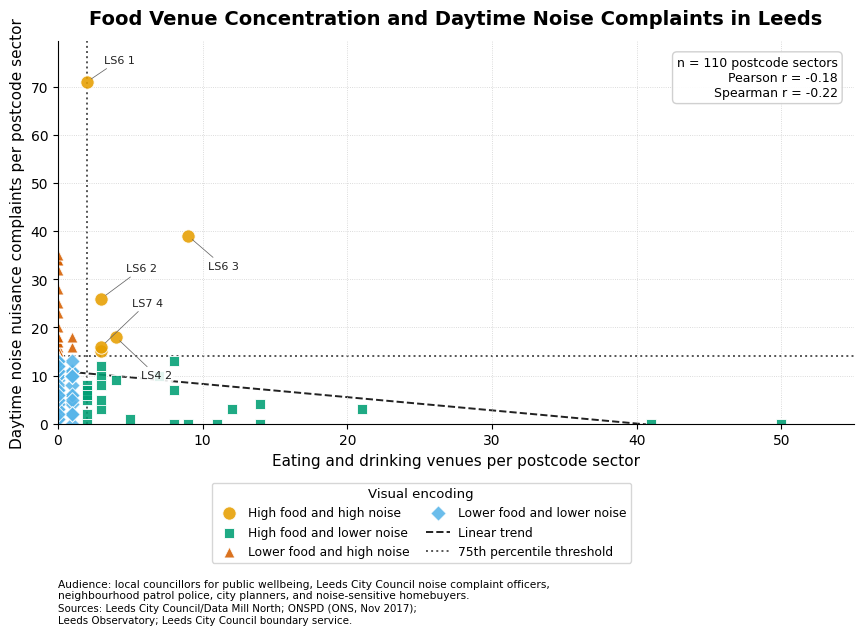

In [24]:
# 10.1 Manage category styles in one place
category_styles = {
    # The priority category uses a larger orange circle
    "High food / high noise": {
        # Set the priority category colour
        "color": "#E69F00",
        # Set the priority marker shape
        "marker": "o",
        # Set the legend label
        "label": "High food and high noise",
        # Set the marker size
        "size": 92,
        # Draw this category above others
        "zorder": 3,
    },
    # High food but lower noise uses a green square
    "High food / lower noise": {
        # Set the category colour
        "color": "#009E73",
        # Set the marker shape
        "marker": "s",
        # Set the legend label
        "label": "High food and lower noise",
        # Set the marker size
        "size": 62,
        # Set the drawing order
        "zorder": 2,
    },
    # Lower food but high noise uses a red-orange triangle
    "Lower food / high noise": {
        # Set the category colour
        "color": "#D55E00",
        # Set the marker shape
        "marker": "^",
        # Set the legend label
        "label": "Lower food and high noise",
        # Set the marker size
        "size": 62,
        # Set the drawing order
        "zorder": 2,
    },
    # Lower food and lower noise uses a blue diamond
    "Lower food / lower noise": {
        # Set the category colour
        "color": "#56B4E9",
        # Set the marker shape
        "marker": "D",
        # Set the legend label
        "label": "Lower food and lower noise",
        # Set the marker size
        "size": 62,
        # Set the drawing order
        "zorder": 2,
    },
}


# 10.2 Extract the colour palette for the spatial map
category_palette = {category: style["color"] for category, style in category_styles.items()}


# 10.3 Add text details
# Source note used in final figure footnotes
visualisation_source_note = (
    # List the main data publishers and lookup source
    "Sources: Leeds City Council/Data Mill North; ONSPD (ONS, Nov 2017);\n"
    # List population and boundary sources
    "Leeds Observatory; Leeds City Council boundary service."
)

# Audience note used by final figures
final_audience_note = (
    "Audience: local councillors for public wellbeing, Leeds City Council noise complaint officers,\n"
    "neighbourhood patrol police, city planners, and noise-sensitive homebuyers."
)

# Extra audience note for the spatial figure
spatial_audience_note = (
    # Start with the shared audience note
    final_audience_note
    # Add the spatial precision note
    + "\nSector centroids show approximate patterns, not exact venue or complaint locations."
)


# 10.4 Define a helper function to add a linear trend line
def add_linear_trend(ax, data):
    # Keep only the two numeric fields needed for the trend line
    trend_data = data[["food_venue_count", "daytime_noise_count"]].dropna()
    # Draw a trend line only if both variables vary
    if trend_data["food_venue_count"].nunique() <= 1 or trend_data["daytime_noise_count"].nunique() <= 1:
        # Skip the trend line if there is no variation
        return
    # x stores food venue count
    x = trend_data["food_venue_count"]
    # y stores daytime noise complaint count
    y = trend_data["daytime_noise_count"]
    # Fit a simple linear trend
    slope, intercept = np.polyfit(x, y, 1)
    # Create x values for a smooth trend line
    x_line = np.linspace(x.min(), x.max(), 100)
    # Calculate y values from the fitted line
    y_line = slope * x_line + intercept
    # Draw the trend line below the points
    ax.plot(x_line, y_line, color="#222222", linestyle="--", linewidth=1.4, label="Linear trend", zorder=1)


# 10.5 Define a helper function to select sectors for labels
def get_priority_label_rows(data, max_labels=5):
    # Select high-food and high-noise sectors first
    label_rows = data[data["food_noise_category"] == "High food / high noise"]
    # If there are no priority sectors, use all sectors
    if label_rows.empty:
        # This keeps labels available in all data versions
        label_rows = data
    # Sort by noise and food counts, then keep the top rows
    return label_rows.sort_values(["daytime_noise_count", "food_venue_count"], ascending=False).head(max_labels)


# 10.6 Define a helper function to draw non-spatial labels
def add_nonspatial_labels(ax, label_rows):
    # Keep all labels to the right of points so they do not overlap the y-axis
    label_offsets = [(12, 12), (14, -18), (18, 18), (18, -24), (22, 28)]
    # Add a label for each selected postcode sector
    for label_index, (_, row) in enumerate(label_rows.iterrows()):
        # Cycle through the offset list
        x_offset, y_offset = label_offsets[label_index % len(label_offsets)]
        # Align all labels to the right of the point
        horizontal_alignment = "left"
        # Align labels above or below depending on the offset direction
        vertical_alignment = "bottom" if y_offset > 0 else "top"
        # Add the sector name beside the point
        ax.annotate(
            # Label text is the postcode sector
            row["postcode_sector"],
            # The label points to the matching scatter point
            (row["food_venue_count"], row["daytime_noise_count"]),
            # Offset the text from the point
            xytext=(x_offset, y_offset),
            # Use screen points as the offset unit
            textcoords="offset points",
            # Use a small label size
            fontsize=8.0,
            # Use dark grey text
            color="#222222",
            # Align the label away from the point horizontally
            ha=horizontal_alignment,
            # Align the label away from the point vertically
            va=vertical_alignment,
            # Use a white box to improve readability
            bbox=dict(boxstyle="round,pad=0.16", facecolor="white", edgecolor="none", alpha=0.88),
            # Draw a thin line to the point
            arrowprops=dict(arrowstyle="-", color="#666666", linewidth=0.55, shrinkA=2, shrinkB=4),
            # Place labels above points and grid lines
            zorder=4,
        )


# 10.7 Prepare the non-spatial figure
# Copy the analysis table so the final plot does not change earlier results
final_nonspatial = sector_analysis.copy()
# Create a compact non-spatial figure
fig, ax = plt.subplots(figsize=(9.2, 6.6))

# 10.8 Draw scatter points by category
# Draw scatter points by category
for category, style in category_styles.items():
    # Select data for the current category
    category_data = final_nonspatial[final_nonspatial["food_noise_category"] == category]
    # Skip empty categories
    if category_data.empty:
        # Move to the next category
        continue
    # Draw the current category
    ax.scatter(
        # x-axis shows food venue count
        category_data["food_venue_count"],
        # y-axis shows daytime noise complaint count
        category_data["daytime_noise_count"],
        # Marker size comes from the style dictionary
        s=style["size"],
        # Marker shape comes from the style dictionary
        marker=style["marker"],
        # Marker colour comes from the style dictionary
        color=style["color"],
        # White edges make overlapping points easier to see
        edgecolors="white",
        # Use a thin marker edge
        linewidth=0.7,
        # Transparency helps show overlap
        alpha=0.88,
        # Legend label comes from the style dictionary
        label=style["label"],
        # Drawing order comes from the style dictionary
        zorder=style["zorder"],
    )

# 10.9 Add trend line, thresholds, and priority labels
# Add a trend line to show the overall direction
add_linear_trend(ax, final_nonspatial)

# Add the 75th percentile threshold for food venues
ax.axvline(food_threshold, color="#555555", linestyle=":", linewidth=1.4, label="75th percentile threshold", zorder=1)
# Add the 75th percentile threshold for noise complaints
ax.axhline(noise_threshold, color="#555555", linestyle=":", linewidth=1.4, zorder=1)

# Select sectors to label
label_sectors = get_priority_label_rows(final_nonspatial)
# Add labels to the scatter plot
add_nonspatial_labels(ax, label_sectors)

# 10.10 Set plot limits and axis styling
# Calculate x-axis maximum for the plot range
x_max = final_nonspatial["food_venue_count"].max()
# Calculate y-axis maximum for the plot range
y_max = final_nonspatial["daytime_noise_count"].max()
# Start the x-axis at 0 and leave space for labels
ax.set_xlim(left=0, right=max(1, x_max) * 1.10)
# Start the y-axis at 0 and leave space for labels
ax.set_ylim(bottom=0, top=max(1, y_max) * 1.12)

# Set a clear figure title
ax.set_title("Food Venue Concentration and Daytime Noise Complaints in Leeds", fontsize=14, fontweight="bold", pad=12)
# Set the x-axis label
ax.set_xlabel("Eating and drinking venues per postcode sector", fontsize=11)
# Set the y-axis label
ax.set_ylabel("Daytime noise nuisance complaints per postcode sector", fontsize=11)
# Add a light grid for easier reading
ax.grid(True, linestyle=":", linewidth=0.6, color="#D0D0D0")
# Hide the top and right spines
for spine in ["top", "right"]:
    # Hide this spine
    ax.spines[spine].set_visible(False)

# 10.11 Add summary statistics annotation
# Add sample size and correlation values inside the plot
ax.text(
    # x position near the right side
    0.98,
    # y position near the top
    0.96,
    # Text includes n, Pearson, and Spearman
    f"n = {len(final_nonspatial)} postcode sectors\nPearson r = {pearson_corr:.2f}\nSpearman r = {spearman_corr:.2f}",
    # Use axis-relative coordinates
    transform=ax.transAxes,
    # Align text to the right
    horizontalalignment="right",
    # Align text to the top
    verticalalignment="top",
    # Set text size
    fontsize=9,
    # Use a white box for readability
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="#CCCCCC", alpha=0.92),
    # Draw above other plot items
    zorder=6,
)

# 10.12 Add legend and figure footnotes
# Get legend handles and labels from the plot
nonspatial_handles, nonspatial_labels = ax.get_legend_handles_labels()
# Place the legend at the bottom of the figure
fig.legend(
    # Use legend handles from the plot
    handles=nonspatial_handles,
    # Use legend labels from the plot
    labels=nonspatial_labels,
    # Set legend title
    title="Visual encoding",
    # Use lower-center placement
    loc="lower center",
    # Put the legend above the footnotes
    bbox_to_anchor=(0.5, 0.100),
    # Use two columns for readability
    ncol=2,
    # Show the legend frame
    frameon=True,
    # Set legend text size
    fontsize=8.8,
    # Set legend title size
    title_fontsize=9.5,
    # Set space between columns
    columnspacing=1.3,
    # Set space between marker and label
    handletextpad=0.6,
)

# Add audience footnote
fig.text(
    # x aligns the footnote with the left side of the plot area
    0.105,
    # y controls vertical position
    0.052,
    # Audience note text
    final_audience_note,
    # Left align the multiline audience note
    horizontalalignment="left",
    # Align multiline text from the bottom
    verticalalignment="bottom",
    # Set footnote size
    fontsize=7.7,
)
# Add source footnote
fig.text(
    # x aligns the source note with the left side of the plot area
    0.105,
    # y controls source footnote position
    0.015,
    # Use multiline source note
    visualisation_source_note,
    # Left align the multiline source note
    horizontalalignment="left",
    # Align multiline text from the bottom
    verticalalignment="bottom",
    # Set source text size
    fontsize=7.4,
)
# Adjust margins for the legend and footnotes
fig.subplots_adjust(left=0.105, right=0.97, top=0.90, bottom=0.32)

# 10.13 Display the non-spatial figure
# Show the figure
plt.show()

## 11. Spatial visualisation output

This session presents the final spatial visualisation of the priority postcode sectors in Leeds. The map shows postcode sector centroids rather than exact venue or complaint locations, because the analysis is carried out at sector level and should not imply more spatial precision than the data supports. Point colour represents the number of daytime noise nuisance complaints, point size represents the number of eating and drinking venues, and the orange outline highlights sectors classified as both high food and high noise. A proportional symbol map is used instead of a choropleth map because the available background boundary is not the same spatial unit as the sector-level statistics, so plotting sector centroids is a more transparent way to show approximate spatial patterns. The map uses the colour-blind friendly cividis colour scale, a separate size legend, labelled priority sectors, and a note explaining the approximate nature of the locations.


---


**AI Acknowledgement:**

I acknowledge the use of Chatgpt - 5.5 Thinking (OpenAI, https://chatgpt.com/) to help debug and improve the final spatial visualisation, especially the legend panel layout, proportional marker scaling, priority-sector labels, boundary checks, north arrow and scale bar.

Prompts:
- My spatial map contains a colourbar, marker-size legend, priority outline, labels, source note and audience note. How can I organise these elements into a clearer layout without making the map too crowded?
- Some postcode-sector centroids may fall outside the Leeds boundary after joining the data. How can I check these points and avoid mapping misleading locations?
- The map marker sizes are too extreme because some sectors have much higher food venue counts. How can I scale marker sizes more clearly for a proportional-symbol map?
- If I rerun only the spatial visualisation section, some shared variables from the previous section may be missing. How can I add fallback definitions to make this section more stable?

Understanding: I have learned how to write helper functions for marker-size scaling, legend construction, map labelling, north arrow, scale bar and map extent control. I also understood how fallback variable checks, boundary filtering and geometry validation can make the spatial visualisation code more modular, stable and reproducible.


The following postcode sector centroids fall outside the Leeds boundary and are not mapped:
postcode_sector  food_venue_count  daytime_noise_count
         LS21 2                 2                    5
         LS25 5                 1                    0
         LS29 6                 1                    2


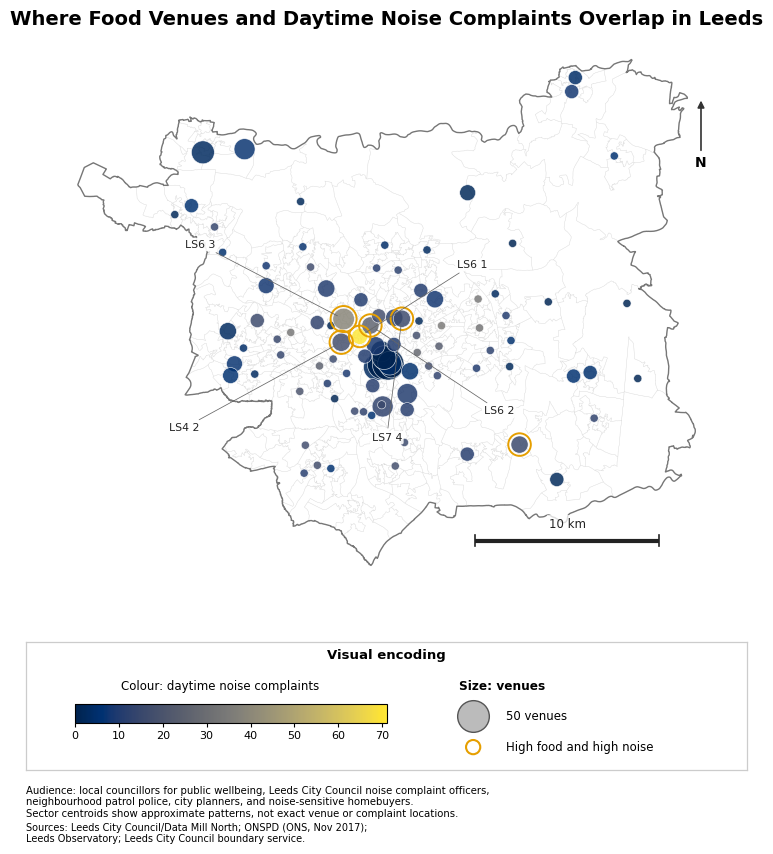

In [25]:
# 11.1 Define fallback shared visual variables

# If #11 is run alone, define the shared colour variable
if "category_palette" not in globals():
    # Only the priority colour is needed here
    category_palette = {"High food / high noise": "#E69F00"}
# If #11 is run alone, define the source note
if "visualisation_source_note" not in globals():
    # Source note
    visualisation_source_note = (
        "Sources: Leeds City Council/Data Mill North; ONSPD (ONS, Nov 2017);\n"
        "Leeds Observatory; Leeds City Council boundary service."
    )
# If #11 is run alone, define the shared audience note
if "final_audience_note" not in globals():
    # Split the audience note into two lines
    final_audience_note = (
        "Audience: local councillors for public wellbeing, Leeds City Council noise complaint officers,\n"
        "neighbourhood patrol police, city planners, and noise-sensitive homebuyers."
    )
# If #11 is run alone, define the spatial audience note
if "spatial_audience_note" not in globals():
    # Add one extra sentence about centroid precision
    spatial_audience_note = (
        final_audience_note
        + "\nSector centroids show approximate patterns, not exact venue or complaint locations."
    )


# 11.2 Define a helper function to scale map marker sizes
def scale_marker_sizes(values, min_size=35, max_size=520):
    # Convert food counts to non-negative floats
    clean_values = values.astype(float).clip(lower=0)
    # Use square root scaling to reduce the effect of extreme values
    sqrt_values = np.sqrt(clean_values)
    # Scale values if there is variation
    if sqrt_values.max() > sqrt_values.min():
        # Return marker sizes scaled to a fixed range
        return np.interp(sqrt_values, [sqrt_values.min(), sqrt_values.max()], [min_size, max_size])
    # If all values are the same, use one medium marker size
    return np.full(len(sqrt_values), (min_size + max_size) / 2)


# 11.3 Define a helper function for legend marker sizes
def marker_size_for_legend(value, reference_values, min_size=35, max_size=520):
    # Convert reference values to non-negative floats
    clean_reference = reference_values.astype(float).clip(lower=0)
    # Apply the same square root scaling as the map points
    sqrt_reference = np.sqrt(clean_reference)
    # Apply square root scaling to the legend value
    sqrt_value = np.sqrt(max(float(value), 0))
    # Use the same scaling rule if the reference values vary
    if sqrt_reference.max() > sqrt_reference.min():
        # Return the marker area for this legend value
        return np.interp(sqrt_value, [sqrt_reference.min(), sqrt_reference.max()], [min_size, max_size])
    # If all point sizes are equal, return a medium size
    return (min_size + max_size) / 2


# 11.4 Define a helper function to add the shared legend panel
def add_spatial_legend_panel(fig, gdf, priority_points, reference_values):
    # Create one shared legend panel
    panel_ax = fig.add_axes([0.06, 0.095, 0.88, 0.145])
    # Hide x-axis ticks
    panel_ax.set_xticks([])
    # Hide y-axis ticks
    panel_ax.set_yticks([])
    # Fix the x range so manual legend items keep their layout
    panel_ax.set_xlim(0, 1)
    # Fix the y range so all legend items use relative positions
    panel_ax.set_ylim(0, 1)
    # Disable autoscaling so legend markers do not change the panel range
    panel_ax.set_autoscale_on(False)
    # Set a white panel background
    panel_ax.set_facecolor("white")
    # Style the panel border
    for spine in panel_ax.spines.values():
        # Set border colour
        spine.set_edgecolor("#CCCCCC")
        # Set border width
        spine.set_linewidth(0.9)
    # Add the shared legend title
    panel_ax.text(0.5, 0.90, "Visual encoding", ha="center", va="center", fontsize=9.5, fontweight="bold")
    # Add the colourbar label
    panel_ax.text(0.27, 0.66, "Colour: daytime noise complaints", ha="center", va="center", fontsize=8.5)
    # Create a small axis for the colourbar
    colorbar_ax = fig.add_axes([0.12, 0.148, 0.38, 0.022])
    # Use a small value and maximum value for marker-size examples
    size_values = [int(round(gdf["food_venue_count"].quantile(q))) for q in [0.25, 1.0]]
    # Remove duplicate and zero values
    size_values = sorted({value for value in size_values if value > 0}) or [0]
    # Add the size legend title on the right
    panel_ax.text(
        # x position aligns with the right-side legend
        0.60,
        # y position places the title above the markers
        0.66,
        # Title explains marker size
        "Size: venues",
        # Left align the title
        ha="left",
        # Centre vertically
        va="center",
        # Set title size
        fontsize=8.7,
        # Use bold text for the encoding name
        fontweight="bold",
    )
    # Set x positions for marker-size examples
    size_marker_x_positions = [0.62, 0.79]
    # Set y position for marker-size examples
    size_marker_y = 0.42
    # Draw each marker-size example
    for value, marker_x in zip(size_values, size_marker_x_positions):
        # Draw a grey circle for the current size
        panel_ax.scatter(
            # x position in panel coordinates
            marker_x,
            # y position in panel coordinates
            size_marker_y,
            # s uses the same area scaling as map points
            s=marker_size_for_legend(value, reference_values),
            # Use grey fill
            facecolor="#BBBBBB",
            # Use dark grey edge
            edgecolor="#555555",
            # Draw above the panel background
            zorder=3,
        )
        # Add the label for the current marker
        panel_ax.text(
            # Put text to the right of the circle
            marker_x + 0.045,
            # Align text with the circle
            size_marker_y,
            # Show the venue count
            f"{value} venues",
            # Left align text
            ha="left",
            # Centre vertically
            va="center",
            # Set text size
            fontsize=8.5,
        )
    # Add the orange outline example if priority sectors exist
    if not priority_points.empty:
        # Set x position for the priority example
        priority_marker_x = 0.62
        # Set y position for the priority example
        priority_marker_y = 0.18
        # Draw the orange outline circle
        panel_ax.scatter(
            # x position
            priority_marker_x,
            # y position
            priority_marker_y,
            # Fixed marker size for the legend
            s=105,
            # No fill, outline only
            facecolor="none",
            # Use the priority colour
            edgecolor=category_palette["High food / high noise"],
            # Set outline width
            linewidth=1.5,
            # Draw above the panel background
            zorder=3,
        )
        # Add the priority label
        panel_ax.text(
            # Put text to the right of the circle
            priority_marker_x + 0.045,
            # Align text with the circle
            priority_marker_y,
            # Explain the orange outline
            "High food and high noise",
            # Left align text
            ha="left",
            # Centre vertically
            va="center",
            # Set text size
            fontsize=8.5,
        )
    # Return the colourbar axis for GeoPandas
    return colorbar_ax


# 11.5 Define a helper function to label key map sectors
def add_spatial_labels(ax, gdf, priority_points, max_labels=5):
    # Label high-food and high-noise sectors first
    label_gdf = (
        # Start from priority points
        priority_points
        # Sort by noise first, then food
        .sort_values(["daytime_noise_count", "food_venue_count"], ascending=False)
        # Keep at most the requested number of labels
        .head(max_labels)
    )
    # If there are no priority sectors, label the highest overall values
    if label_gdf.empty:
        # Select highest sectors from the full spatial data
        label_gdf = gdf.sort_values(["daytime_noise_count", "food_venue_count"], ascending=False).head(max_labels)
    # Use larger offsets to pull labels away from dense point clusters
    offsets = [
        # First label goes upper right
        (70, 48),
        # Second label goes upper left
        (-92, 50),
        # Third label goes lower right
        (82, -58),
        # Fourth label goes lower left
        (-102, -58),
        # Fifth label goes below the cluster
        (0, -82),
    ]
    # Draw each map label
    for label_index, (_, row) in enumerate(label_gdf.iterrows()):
        # Select the current offset
        x_offset, y_offset = offsets[label_index % len(offsets)]
        # If x offset is positive, align text left
        horizontal_alignment = "left" if x_offset > 0 else "right"
        # If y offset is positive, align text bottom
        vertical_alignment = "bottom" if y_offset > 0 else "top"
        # Add the sector label
        ax.annotate(
            # Label text is postcode sector
            row["postcode_sector"],
            # Arrow points to sector centroid
            xy=(row.geometry.x, row.geometry.y),
            # Offset text from the centroid
            xytext=(x_offset, y_offset),
            # Offset unit is screen points
            textcoords="offset points",
            # Set label size
            fontsize=7.8,
            # Set label colour
            color="#222222",
            # Set horizontal alignment
            ha=horizontal_alignment,
            # Set vertical alignment
            va=vertical_alignment,
            # Use a white label box
            bbox=dict(boxstyle="round,pad=0.16", facecolor="white", edgecolor="none", alpha=0.90),
            # Use a thin arrow line
            arrowprops=dict(arrowstyle="-", color="#666666", linewidth=0.55, shrinkA=2, shrinkB=5),
            # Do not clip labels near the map edge
            annotation_clip=False,
            # Draw labels above other layers
            zorder=5,
        )


# 11.6 Define a helper function to add a north arrow
def add_north_arrow(ax):
    # Add a north arrow in the upper-right blank area
    ax.annotate(
        # North arrow text
        "N",
        # Arrow points upward near the right edge
        xy=(0.985, 0.90),
        # Text sits below the arrow
        xytext=(0.985, 0.78),
        # Use axis-relative coordinates for arrow
        xycoords="axes fraction",
        # Use axis-relative coordinates for text
        textcoords="axes fraction",
        # Centre horizontally
        ha="center",
        # Centre vertically
        va="center",
        # Set text size
        fontsize=10,
        # Use bold text
        fontweight="bold",
        # Add a white background behind N
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.80, pad=1.5),
        # Set arrow style
        arrowprops=dict(arrowstyle="-|>", color="#333333", linewidth=1.2),
        # Do not clip the arrow near the edge
        annotation_clip=False,
    )


# 11.7 Define a helper function to add a scale bar
def add_scale_bar(ax, length_m=10000, label="10 km"):
    # Read current x-axis range
    x_left, x_right = ax.get_xlim()
    # Read current y-axis range
    y_bottom, y_top = ax.get_ylim()
    # Place the scale bar in the lower-right blank area
    scale_x = x_right - length_m - (x_right - x_left) * 0.08
    # Set scale bar y position
    scale_y = y_bottom + (y_top - y_bottom) * 0.075
    # Set tick height
    tick_height = (y_top - y_bottom) * 0.010
    # Draw the main scale bar line
    ax.plot(
        # Line runs from left to right
        [scale_x, scale_x + length_m],
        # Keep the same y coordinate
        [scale_y, scale_y],
        # Use dark grey
        color="#222222",
        # Use a thicker main line
        linewidth=3,
        # Keep line ends flat
        solid_capstyle="butt",
        # Draw above the map
        zorder=6,
    )
    # Draw ticks at both ends
    for tick_x in [scale_x, scale_x + length_m]:
        # Draw the current tick
        ax.plot(
            # Tick x coordinate
            [tick_x, tick_x],
            # Tick y range
            [scale_y - tick_height, scale_y + tick_height],
            # Use dark grey
            color="#222222",
            # Use a thinner tick line
            linewidth=1.2,
            # Draw above the map
            zorder=6,
        )
    # Add the scale label
    ax.text(
        # Place text in the middle
        scale_x + length_m / 2,
        # Place text above the line
        scale_y + tick_height * 1.9,
        # Show scale length
        label,
        # Centre horizontally
        ha="center",
        # Align text bottom
        va="bottom",
        # Set text size
        fontsize=8.5,
        # Set text colour
        color="#222222",
        # Add a white background
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1.5),
        # Draw above the map
        zorder=6,
    )


# 11.8 Define a helper function to set the map extent
def set_map_extent(ax, boundary, buffer_ratio=0.025):
    # Read boundary extent
    minx, miny, maxx, maxy = boundary.total_bounds
    # Calculate a small map buffer
    map_buffer = max(maxx - minx, maxy - miny) * buffer_ratio
    # Set x-axis range
    ax.set_xlim(minx - map_buffer, maxx + map_buffer)
    # Set y-axis range
    ax.set_ylim(miny - map_buffer, maxy + map_buffer)
    # Keep the map aspect ratio correct
    ax.set_aspect("equal")


# 11.9 Prepare spatial data and priority points
# Prepare spatial data and keep sectors with geometry
final_spatial_gdf = sector_analysis_gdf[sector_analysis_gdf.geometry.notna()].copy()
# Drop old category field to avoid duplicate columns
final_spatial_gdf = final_spatial_gdf.drop(columns=["food_noise_category"], errors="ignore")
# Rejoin the same category field used in the non-spatial plot
final_spatial_gdf = final_spatial_gdf.merge(
    # Join only sector name and category
    sector_analysis[["postcode_sector", "food_noise_category"]],
    # Use postcode_sector as the key
    on="postcode_sector",
    # Keep all sectors with geometry
    how="left",
)
# Convert back to a GeoDataFrame
final_spatial_gdf = gpd.GeoDataFrame(final_spatial_gdf, geometry="geometry", crs=sector_analysis_gdf.crs)
# Fill missing categories with the lower/lower category
final_spatial_gdf["food_noise_category"] = final_spatial_gdf["food_noise_category"].fillna("Lower food / lower noise")
# Dissolve Leeds boundary to check whether points fall inside it
leeds_outline = leeds_boundary.dissolve()
# Get the dissolved Leeds boundary geometry
leeds_outline_geometry = leeds_outline.geometry.iloc[0]
# Check whether each sector centroid intersects the Leeds boundary
inside_leeds_boundary = final_spatial_gdf.geometry.intersects(leeds_outline_geometry)
# Save points outside the boundary for checking
outside_boundary_points = final_spatial_gdf[~inside_leeds_boundary].copy()
# Print outside-boundary points if any exist
if not outside_boundary_points.empty:
    # Print the warning message
    print("\nThe following postcode sector centroids fall outside the Leeds boundary and are not mapped:")
    # Print key fields for checking
    print(
        outside_boundary_points[
            # Show only fields needed for interpretation
            ["postcode_sector", "food_venue_count", "daytime_noise_count"]
        ].to_string(index=False)
    )
# Keep only centroids inside the Leeds boundary for the final map
final_spatial_gdf = final_spatial_gdf[inside_leeds_boundary].copy()
# Get food venue counts for marker scaling
food_count = final_spatial_gdf["food_venue_count"]
# Calculate marker size for each sector
final_spatial_gdf["marker_size"] = scale_marker_sizes(food_count)
# Select high-food and high-noise priority sectors
priority_map_points = final_spatial_gdf[final_spatial_gdf["food_noise_category"] == "High food / high noise"].copy()

# 11.10 Create the spatial figure and legend panel
# Create the spatial figure
fig, ax = plt.subplots(figsize=(8.2, 8.8))
# Adjust margins for the legend panel and footnotes
fig.subplots_adjust(left=0.035, right=0.965, top=0.92, bottom=0.31)
# Create the shared legend panel and colourbar axis
noise_colorbar_ax = add_spatial_legend_panel(fig, final_spatial_gdf, priority_map_points, food_count)

# 11.11 Draw Leeds boundary context
# Draw internal LSOA boundaries as a light grey background
leeds_boundary.boundary.plot(ax=ax, color="#D6D6D6", linewidth=0.25, alpha=0.65, zorder=1)
# Draw the Leeds outer boundary
leeds_outline.boundary.plot(ax=ax, color="#777777", linewidth=1.0, zorder=2)

# 11.12 Draw proportional sector points
# Set the maximum value for the noise colour scale
noise_vmax = max(1, final_spatial_gdf["daytime_noise_count"].max())
# Draw postcode sector centroids
final_spatial_gdf.plot(
    # Draw on the main map axis
    ax=ax,
    # Use the colourbar axis in the legend panel
    cax=noise_colorbar_ax,
    # Point colour shows daytime noise complaints
    column="daytime_noise_count",
    # cividis is a colour-blind friendly continuous colourmap
    cmap="cividis",
    # Start colour scale at 0
    vmin=0,
    # Use the data maximum for colour scale
    vmax=noise_vmax,
    # Point size shows food venue count
    markersize=final_spatial_gdf["marker_size"],
    # Slight transparency keeps the boundary visible
    alpha=0.84,
    # White edges separate nearby points
    edgecolor="white",
    # Set point edge width
    linewidth=0.45,
    # Show the colourbar
    legend=True,
    # Horizontal colourbar; label is handled by panel text
    legend_kwds={"label": "", "orientation": "horizontal"},
    # Draw points above boundaries
    zorder=3,
)
# Set colourbar tick style
noise_colorbar_ax.tick_params(labelsize=8, length=3, pad=2)
# Remove default colourbar label
noise_colorbar_ax.set_xlabel("")

# 11.13 Highlight and label priority sectors
# Highlight priority sectors with orange outlines
if not priority_map_points.empty:
    # Draw the priority sector outline
    ax.scatter(
        # x coordinates from geometry
        priority_map_points.geometry.x,
        # y coordinates from geometry
        priority_map_points.geometry.y,
        # Outline is larger than the original point
        s=priority_map_points["marker_size"] + 110,
        # No fill colour
        facecolors="none",
        # Use priority colour for outline
        edgecolors=category_palette["High food / high noise"],
        # Set outline width
        linewidths=1.4,
        # Draw above normal points
        zorder=4,
    )

# Add labels for key sectors
add_spatial_labels(ax, final_spatial_gdf, priority_map_points)

# 11.14 Finalise map layout and annotation
# Set map extent
set_map_extent(ax, leeds_boundary)
# Set spatial figure title
ax.set_title("Where Food Venues and Daytime Noise Complaints Overlap in Leeds", fontsize=14, fontweight="bold", pad=14)
# Add north arrow
add_north_arrow(ax)
# Add 10 km scale bar
add_scale_bar(ax)
# Hide axes for a clean map
ax.set_axis_off()

# 11.15 Add footnotes and display the spatial figure
# Add audience and spatial precision note
fig.text(
    # x aligns the footnote with the left side of the map figure
    0.060,
    # y controls footnote position
    0.040,
    # Audience and precision note
    spatial_audience_note,
    # Left align the multiline audience and precision note
    horizontalalignment="left",
    # Align multiline text from the bottom
    verticalalignment="bottom",
    # Set footnote text size
    fontsize=7.3,
)
# Add spatial figure source note
fig.text(
    # x aligns the source note with the left side of the map figure
    0.060,
    # y controls source note position
    0.011,
    # Use multiline source note
    visualisation_source_note,
    # Left align the multiline source note
    horizontalalignment="left",
    # Align multiline text from the bottom
    verticalalignment="bottom",
    # Set source note text size
    fontsize=7.0,
)
# Show the map
plt.show()

The analysis shows no strong city-wide link between food venue concentration and daytime noise complaints in Leeds. The scatter plot reveals a weak negative association (*Pearson r = -0.18, Spearman r = -0.22*), showing that more venues do not guarantee more complaints.

However, spatial analysis highlights specific local patterns. Sectors like **LS6 1, LS6 2, LS6 3, LS7 4, and LS4 2** are *high food/high noise* areas, primarily clustered around central and inner Leeds. This indicates a localized, rather than city-wide, situation.

In conclusion, daytime noise complaints are not a simple consequence of high venue density. Instead, the focus should be on these localized hotspots, which warrant further investigation by local authorities and planners before making policy or licensing decisions.



---


# **Gen AI use acknowledgement**

I acknowledge the use of Chatgpt - 5.5 Thinking (OpenAI, https://chatgpt.com/) to assist in writing the code, in order to solve the operational difficulties in the data preprocessing process, guide the definition of functions for standardized data cleaning, provide ideas for building models to evaluate variable relationships, and enhance the visualization effects of advanced charts and maps. And during the process of my writing the comments, Chatgpt - 5.5 Thinking (OpenAI, https://chatgpt.com/) also help me optimize the code explanations, as well as assist with the translation from Chinese to English. The specific usage situation is indicated within the code.

# **References**

[1] Kabe, M. and Ito, K. 2008. Color universal design (CUD): How to make figures and presentations that are friendly to colorblind people. [Online]. [Accessed 27 April 2026]. Available from: https://jfly.uni-koeln.de/color/

[2] Locke, K.A. 2024. Modelling relationships between land use and water quality using statistical methods: A critical and applied review. Journal of Environmental Management. [Online]. 362, article no: 121290 [no pagination]. [Accessed 26 April 2026]. Available from: https://doi.org/10.1016/j.jenvman.2024.121290

[3] Mutz, R. and Daniel, H.-D. 2019. How to consider fractional counting and field normalization in the statistical modeling of bibliometric data: A multilevel Poisson regression approach. Journal of Informetrics. [Online]. 13(2), pp.643–657. [Accessed 28 April 2026]. Available from: https://doi.org/10.1016/j.joi.2019.03.007

[4] Suryadi, F., Jonathan, S., Jonatan, K. and Ohyver, M. 2023. Handling overdispersion in poisson regression using negative binomial regression for poverty case in west java. Procedia Computer Science. [Online]. 216, pp.517–523. [Accessed 27 April 2026]. Available from: https://doi.org/10.1016/j.procs.2022.12.164

[5] World Health Organization Regional Office for Europe 2018. Environmental noise guidelines for the European Region. Copenhagen: WHO Regional Office for Europe. [Online]. [Accessed 26 April 2026]. Available from: https://www.who.int/publications/i/item/9789289053563

[6] Zhang, Y., Qin, Q., Nie, H., Kwan, M.-P., He, S. and Ke, E. 2026. Cross-city traffic noise modeling and inequality analysis via AlphaEarth geospatial foundation models. Transportation Research Part D: Transport and Environment. [Online]. 156, article no: 105378 [no pagination]. [Accessed 27 April 2026]. Available from: https://doi.org/10.1016/j.trd.2026.105378